In [1]:
import pandas as pd
dataset = pd.read_csv("../processed_data/ml_dataset.csv")

In [2]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# --- Split your data ---
X = dataset.drop(columns=['CRIME_HAPPENED'])
y = dataset['CRIME_HAPPENED']

X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# 80/10/10 split
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1111, random_state=42, stratify=y_train_val
)

# --- Create LightGBM datasets ---
train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

# --- Parameters ---
params = {
    'objective': 'binary',  #  binarna klasifikacija
    'boosting_type': 'gbdt', # Gradient Boosted Decision Trees
    'learning_rate': 0.05, # Koliko model polako uči manji-sporije uči, ali obično precizniji, veći-bržeali može da promaši, tipično:0.01–0.1
    'num_leaves': 31, # Koliko kompleksno drvo može da bude (više-hvata kompleksnije obrasce, ali overfittuje), (manje - jednostavniji model)
    'max_depth': -1, # maks dubina stabla, - 1 je da nema limita
    'feature_fraction': 0.8, # Model koristi 80% feature-a po stablu, efekat: manje overfittinga, više generalizacije
    'bagging_fraction': 0.8, # Koristi 80% podataka po iteraciji
    'bagging_freq': 5, # Radi bagging svakih 5 iteracija
    'seed': 42, # da dobijaš iste rezultate svaki put
    'metric': 'binary_logloss'  #To je način na koji model meri koliko greši tokom treninga. Ne gleda samo da li je pogodio 0 ili 1, nego koliko je bio siguran u tu odluku
}

# --- Train model ---
model = lgb.train(
    params,
    train_data,
    num_boost_round=500,          # number of iterations
    valid_sets=[train_data, val_data],
    valid_names=['train', 'val']
)

# --- Predict ---
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

# --- Evaluate ---
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

[LightGBM] [Info] Number of positive: 166156, number of negative: 166156
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003628 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1499
[LightGBM] [Info] Number of data points in the train set: 332312, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Accuracy: 0.7489
Precision: 0.7229
Recall: 0.8070
F1-score: 0.7627


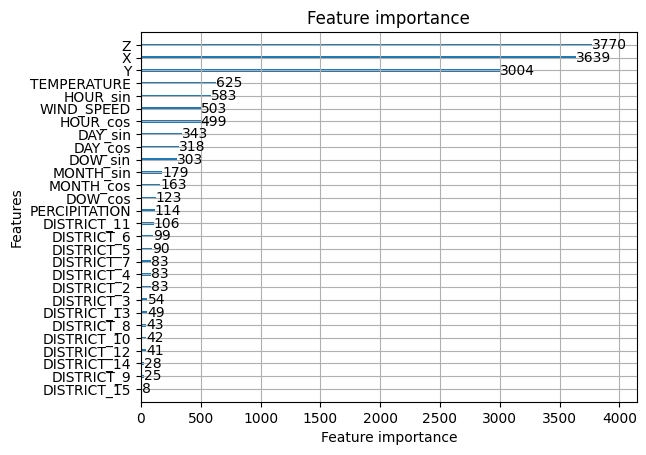

In [3]:
import matplotlib.pyplot as plt
lgb.plot_importance(model)
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
import lightgbm as lgb

model = lgb.LGBMClassifier()

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 100],
    'max_depth': [-1, 10, 20],
    'min_child_samples': [20, 50, 100],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [0, 0.1, 0.5],
    'feature_fraction': [0.6, 0.8, 1.0],
    'bagging_fraction': [0.6, 0.8, 1.0]
}

grid = GridSearchCV(model, param_grid, scoring='f1', cv=3)
grid.fit(X_train, y_train)

print(grid.best_params_)

[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Warning] feature_fraction is set=0.6, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
[LightGBM] [Info] Number of positive: 110770, number of negative: 110771
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012730 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1499
[LightGBM] [Info] Number of data points in the train set: 221541, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499998 -> initscore=-0.000009
[LightGBM] [Info] Start training from score -0.000009
[LightGBM] [Warning] 

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# --- Split your data ---
X = dataset.drop(columns=['CRIME_HAPPENED'])
y = dataset['CRIME_HAPPENED']

X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

# 80/10/10 split
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1111, random_state=42, stratify=y_train_val
)

# --- Create LightGBM datasets ---
train_data = lgb.Dataset(X_train, label=y_train)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data)

# --- Parameters ---
params = {
    'objective': 'binary',
    'learning_rate': 0.1,
    'num_leaves': 100,
    'max_depth': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'seed': 42,
    'metric': 'binary_logloss'
}

# --- Train model ---
model = lgb.train(
    params,
    train_data,
    num_boost_round=500,          # number of iterations
    valid_sets=[train_data, val_data],
    valid_names=['train', 'val']
)

# --- Predict ---
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob >= 0.5).astype(int)

# --- Evaluate ---
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")